In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, classification_report
from sklearn.inspection import permutation_importance
import scipy.stats as stats
from catboost import CatBoostRegressor, Pool, CatBoostClassifier

### Catboost With Leakage (Modelo 1)

In [3]:
df = pd.read_csv('/content/df_train_2_FE.csv')

df_val = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Datasets/df_val_2_FE_sinOutliers.csv')

df.dropna(inplace=True)

df['key'] = df['key'].astype(str)
df['mode'] = df['mode'].astype(str)
df['grupo_anio'] = df['grupo_anio'].astype(str)
df['len_playlist_name'] = df['len_playlist_name'].astype(str)
df['tonality'] = df['tonality'].astype(str)

df['distance_mean_duration_min'] = (df['duration_min'] - df['duration_min'].mean())
df['distance_sq_mean_duration_min'] = (df['distance_mean_duration_min'])**2
df['log_duration_min'] = np.log(df['duration_min'])
df['z_duration_min'] = (df['duration_min'] - df['duration_min'].mean())/df['duration_min'].std()

# FE de tiempo
df['tiene_mes_y_dia'] = (df['track_album_release_date'].apply(lambda x: x.count('-')) == 2).astype(int)
serie_tiempo = pd.to_datetime(df.loc[df['tiene_mes_y_dia'] == 1, 'track_album_release_date'])
df['mes'] = 13
df.loc[df['tiene_mes_y_dia'] == 1, 'mes'] = serie_tiempo.dt.month
df['dia'] = 32
df.loc[df['tiene_mes_y_dia'] == 1, 'dia'] = serie_tiempo.dt.day
df['tiene_mes_y_dia'] = df['tiene_mes_y_dia'].astype(str)
df['mes'] = df['mes'].astype(str)
df['dia'] = df['dia'].astype(str)

df_val['tiene_mes_y_dia'] = (df_val['track_album_release_date'].apply(lambda x: x.count('-')) == 2).astype(int)
serie_tiempo = pd.to_datetime(df_val.loc[df_val['tiene_mes_y_dia'] == 1, 'track_album_release_date'])
df_val['mes'] = 13
df_val.loc[df_val['tiene_mes_y_dia'] == 1, 'mes'] = serie_tiempo.dt.month
df_val['dia'] = 32
df_val.loc[df_val['tiene_mes_y_dia'] == 1, 'dia'] = serie_tiempo.dt.day
df_val['tiene_mes_y_dia'] = df_val['tiene_mes_y_dia'].astype(str)
df_val['mes'] = df_val['mes'].astype(str)
df_val['dia'] = df_val['dia'].astype(str)


df_val['log_duration_min'] = np.log(df_val['duration_min'])
df_val['z_duration_min'] = (df_val['duration_min'] - df['duration_min'].mean())/df['duration_min'].std()

In [4]:
# Corriendo con esta da igual al csv catboost_leakage.csv
df_inicial = df[['Unnamed: 0', 'track_id', 'track_name', 'track_artist',
       'track_popularity', 'track_album_id', 'track_album_name',
       'playlist_name', 'playlist_id',
       'playlist_genre', 'playlist_subgenre', 'danceability', 'energy',
       'loudness', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_min', 'grupo_anio', 'tonality',
                 'tiene_mes_y_dia', 'mes', 'dia'
                 ]]

df_inicial_FE = df_inicial.copy()
df_inicial_FE['distance_mean_danceability'] = (df_inicial_FE['danceability'] - df_val['danceability'].mean())
df_inicial_FE['distance_sq_mean_danceability'] = (df_inicial_FE['distance_mean_danceability'])**2
df_inicial_FE['distance_mean_energy'] = (df_inicial_FE['energy'] - df_val['energy'].mean())
df_inicial_FE['distance_sq_mean_energy'] = (df_inicial_FE['distance_mean_energy'])**2
df_inicial_FE['distance_mean_loudness'] = (df_inicial_FE['loudness'] - df_val['loudness'].mean())
df_inicial_FE['distance_sq_mean_loudness'] = (df_inicial_FE['distance_mean_loudness'])**2
df_inicial_FE['distance_mean_speechiness'] = (df_inicial_FE['speechiness'] - df_val['speechiness'].mean())
df_inicial_FE['distance_sq_mean_speechiness'] = (df_inicial_FE['distance_mean_speechiness'])**2
df_inicial_FE['distance_mean_acousticness'] = (df_inicial_FE['acousticness'] - df_val['acousticness'].mean())
df_inicial_FE['distance_sq_mean_acousticness'] = (df_inicial_FE['distance_mean_acousticness'])**2
df_inicial_FE['distance_mean_liveness'] = (df_inicial_FE['liveness'] - df_val['liveness'].mean())
df_inicial_FE['distance_sq_mean_liveness'] = (df_inicial_FE['distance_mean_liveness'])**2
df_inicial_FE['distance_mean_valence'] = (df_inicial_FE['valence'] - df_val['valence'].mean())
df_inicial_FE['distance_sq_mean_valence'] = (df_inicial_FE['distance_mean_valence'])**2
df_inicial_FE['distance_mean_tempo'] = (df_inicial_FE['tempo'] - df_val['tempo'].mean())
df_inicial_FE['distance_sq_mean_tempo'] = (df_inicial_FE['distance_mean_tempo'])**2
df_inicial_FE['distance_mean_duration_min'] = (df_inicial_FE['duration_min'] - df_val['duration_min'].mean())
df_inicial_FE['distance_sq_mean_duration_min'] = (df_inicial_FE['distance_mean_duration_min'])**2

X = df_inicial_FE.drop(columns=['Unnamed: 0', 'track_popularity'])
y = df_inicial_FE['track_popularity']

Correr el modelo

In [5]:
# Sacamos algunas variables que podian hacer muy notable el overfitting
X_reduced = X.drop(columns=['track_name','track_album_name','playlist_name','playlist_id','playlist_genre','playlist_subgenre'])
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)
cat_features = X_reduced.select_dtypes(include='object').columns.tolist()
train_pool = Pool(X_train, y_train, cat_features=cat_features)

model = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.01,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=100
)

# ── ENTRENAMIENTO ──────────────────────────────────────────────
model.fit(train_pool)

print('TRAIN')
y_pred = model.predict(X_train)
print(f"R²:   {r2_score(y_train, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred)):.4f}")

print('TEST')
y_pred = model.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

0:	learn: 0.0055168	total: 133ms	remaining: 2m 39s
100:	learn: 0.2726930	total: 4.55s	remaining: 49.6s
200:	learn: 0.3705629	total: 8.37s	remaining: 41.6s
300:	learn: 0.3937823	total: 12.9s	remaining: 38.6s
400:	learn: 0.4048310	total: 17s	remaining: 33.9s
500:	learn: 0.4125231	total: 21.2s	remaining: 29.6s
600:	learn: 0.4181480	total: 26.6s	remaining: 26.5s
700:	learn: 0.4232485	total: 30.8s	remaining: 21.9s
800:	learn: 0.4278569	total: 35.2s	remaining: 17.5s
900:	learn: 0.4319411	total: 40.7s	remaining: 13.5s
1000:	learn: 0.4362931	total: 45s	remaining: 8.95s
1100:	learn: 0.4403404	total: 49.7s	remaining: 4.46s
1199:	learn: 0.4437758	total: 55s	remaining: 0us
TRAIN
R²:   0.7622
RMSE: 12.1763
TEST
R²:   0.4878
RMSE: 17.9344


Con X completo:

TRAIN
R²:   0.7665
RMSE: 12.0654
TEST
R²:   0.5145
RMSE: 17.4591


Con segundo X:
TRAIN
R²:   0.7625
RMSE: 12.1674
TEST
R²:   0.4856
RMSE: 17.9721

Para la submission

In [6]:
df_val_inicial = df_val[['Unnamed: 0', 'track_id', 'track_name', 'track_artist',
       'track_album_id', 'track_album_name','playlist_name', 'playlist_id','playlist_genre', 'playlist_subgenre',
        'danceability', 'energy','loudness', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_min', 'grupo_anio', 'tonality',
                         'tiene_mes_y_dia', 'mes', 'dia']].copy()
df_val_inicial_FE = df_val_inicial.copy()
df_val_inicial_FE = df_val_inicial_FE.drop(columns=['Unnamed: 0', 'track_name','track_album_name','playlist_name','playlist_id','playlist_genre','playlist_subgenre'])
df_val_inicial_FE['distance_mean_danceability'] = (df_val_inicial_FE['danceability'] - df_val['danceability'].mean())
df_val_inicial_FE['distance_sq_mean_danceability'] = (df_val_inicial_FE['distance_mean_danceability'])**2
df_val_inicial_FE['distance_mean_energy'] = (df_val_inicial_FE['energy'] - df_val['energy'].mean())
df_val_inicial_FE['distance_sq_mean_energy'] = (df_val_inicial_FE['distance_mean_energy'])**2
df_val_inicial_FE['distance_mean_loudness'] = (df_val_inicial_FE['loudness'] - df_val['loudness'].mean())
df_val_inicial_FE['distance_sq_mean_loudness'] = (df_val_inicial_FE['distance_mean_loudness'])**2
df_val_inicial_FE['distance_mean_speechiness'] = (df_val_inicial_FE['speechiness'] - df_val['speechiness'].mean())
df_val_inicial_FE['distance_sq_mean_speechiness'] = (df_val_inicial_FE['distance_mean_speechiness'])**2
df_val_inicial_FE['distance_mean_acousticness'] = (df_val_inicial_FE['acousticness'] - df_val['acousticness'].mean())
df_val_inicial_FE['distance_sq_mean_acousticness'] = (df_val_inicial_FE['distance_mean_acousticness'])**2
df_val_inicial_FE['distance_mean_liveness'] = (df_val_inicial_FE['liveness'] - df_val['liveness'].mean())
df_val_inicial_FE['distance_sq_mean_liveness'] = (df_val_inicial_FE['distance_mean_liveness'])**2
df_val_inicial_FE['distance_mean_valence'] = (df_val_inicial_FE['valence'] - df_val['valence'].mean())
df_val_inicial_FE['distance_sq_mean_valence'] = (df_val_inicial_FE['distance_mean_valence'])**2
df_val_inicial_FE['distance_mean_tempo'] = (df_val_inicial_FE['tempo'] - df_val['tempo'].mean())
df_val_inicial_FE['distance_sq_mean_tempo'] = (df_val_inicial_FE['distance_mean_tempo'])**2
df_val_inicial_FE['distance_mean_duration_min'] = (df_val_inicial_FE['duration_min'] - df_val['duration_min'].mean())
df_val_inicial_FE['distance_sq_mean_duration_min'] = (df_val_inicial_FE['distance_mean_duration_min'])**2


y_val_predicted = model.predict(df_val_inicial_FE[X_reduced.columns.tolist()])

submision_df = pd.DataFrame({'ID': df_val_inicial['Unnamed: 0'], 'track_popularity': y_val_predicted - 6})
# submision_df.to_csv('catboost_with_leakage.csv', index=False)

## Track_id

### Parte inicial Track_id

In [7]:
df = pd.read_csv('/content/df_train_2_FE.csv')

df_val = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Datasets/df_val_2_FE_sinOutliers.csv')

df.dropna(inplace=True)
df['key'] = df['key'].astype(str)
df['mode'] = df['mode'].astype(str)
df['grupo_anio'] = df['grupo_anio'].astype(str)
df['len_playlist_name'] = df['len_playlist_name'].astype(str)
df['tonality'] = df['tonality'].astype(str)

# FE de tiempo
df['tiene_mes_y_dia'] = (df['track_album_release_date'].apply(lambda x: x.count('-')) == 2).astype(int)
serie_tiempo = pd.to_datetime(df.loc[df['tiene_mes_y_dia'] == 1, 'track_album_release_date'])
df['mes'] = 13
df.loc[df['tiene_mes_y_dia'] == 1, 'mes'] = serie_tiempo.dt.month
df['dia'] = 32
df.loc[df['tiene_mes_y_dia'] == 1, 'dia'] = serie_tiempo.dt.day
df['tiene_mes_y_dia'] = df['tiene_mes_y_dia'].astype(str)
df['mes'] = df['mes'].astype(str)
df['dia'] = df['dia'].astype(str)

df_val['tiene_mes_y_dia'] = (df_val['track_album_release_date'].apply(lambda x: x.count('-')) == 2).astype(int)
serie_tiempo = pd.to_datetime(df_val.loc[df_val['tiene_mes_y_dia'] == 1, 'track_album_release_date'])
df_val['mes'] = 13
df_val.loc[df_val['tiene_mes_y_dia'] == 1, 'mes'] = serie_tiempo.dt.month
df_val['dia'] = 32
df_val.loc[df_val['tiene_mes_y_dia'] == 1, 'dia'] = serie_tiempo.dt.day
df_val['tiene_mes_y_dia'] = df_val['tiene_mes_y_dia'].astype(str)
df_val['mes'] = df_val['mes'].astype(str)
df_val['dia'] = df_val['dia'].astype(str)

In [8]:
cols = ['Unnamed: 0','track_artist', 'playlist_name', 'playlist_id',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'grupo_anio',
       'distance_mean_danceability', 'distance_sq_mean_danceability', 'distance_mean_energy',
       'distance_sq_mean_energy', 'distance_mean_loudness',
       'distance_sq_mean_loudness', 'distance_mean_speechiness',
       'distance_sq_mean_speechiness', 'distance_mean_acousticness',
       'distance_sq_mean_acousticness', 'distance_mean_liveness',
       'distance_sq_mean_liveness', 'distance_mean_valence',
       'distance_sq_mean_valence', 'distance_mean_tempo',
       'distance_sq_mean_tempo', 'dance_energy', 'happy_energy',
       'acoustic_instr', 'duration_min', 'track_age', 'len_playlist_name',
       'log_instrumentalness', 'log_speechiness', 'log_liveness', 'z_danceability', 'z_energy', 'z_loudness', 'z_tempo',
       'z_valence', 'z_acousticness', 'z_instrumentalness', 'z_speechiness',
       'global_atipicality', 'max_z_score',
       'most_extreme_feature', 'mood_score', 'chill_score', 'melancholy_score',
       'radio_friendly', 'club_score', 'acoustic_contrast', 'mood_complexity',
       'dance_val_tension', 'vocal_presence', 'pure_instrumental',
       'spoken_word', 'loudness_abs', 'loudness_energy_ratio',
       'dynamic_compression', 'live_vocal', 'studio_clean', 'danceability_sq',
       'danceability_sqrt', 'energy_sq', 'energy_sqrt', 'valence_sq',
       'valence_sqrt', 'loudness_abs_sq', 'loudness_abs_sqrt', 'tonality',
        'tiene_mes_y_dia', 'mes', 'dia']

dummies_genre = pd.get_dummies(df['playlist_genre']).astype(int)
dummies_subgenre = pd.get_dummies(df['playlist_subgenre']).astype(int)
genre_imp = dummies_genre[['r&b']]
subgenre_imp = dummies_subgenre[['neo soul']]

copia = df.copy()

df_1 = pd.concat([copia[cols], genre_imp, subgenre_imp], axis=1)

df_1['distance_mean_duration_min'] = (df['duration_min'] - df['duration_min'].mean())
df_1['distance_sq_mean_duration_min'] = (df_1['distance_mean_duration_min'])**2
df_1['log_duration_min'] = np.log(df['duration_min'])
df_1['z_duration_min'] = (df['duration_min'] - df['duration_min'].mean())/df['duration_min'].std()

df_1['r&b'] = df_1['r&b'].astype(str)
df_1['neo soul'] = df_1['neo soul'].astype(str)

In [9]:
X = df_1.copy()
y = df['track_popularity'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_true, X_val, y_train_true, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

cat_features = df_1.select_dtypes(include='object').columns.tolist()
train_pool = Pool(X_train_true, y_train_true, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_features)

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.025,
    loss_function='RMSE',
    eval_metric='RMSE',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)

# ── ENTRENAMIENTO ──────────────────────────────────────────────
model.fit(train_pool, eval_set=val_pool)

print('TRAIN')
y_pred = model.predict(X_train_true)
print(f"R²:   {r2_score(y_train_true, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train_true, y_pred)):.4f}")

print('VAL')
y_pred = model.predict(X_val)
print(f"R²:   {r2_score(y_val, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred)):.4f}")

print('TEST')
y_pred = model.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

0:	learn: 24.8557575	test: 24.5192869	best: 24.5192869 (0)	total: 67.6ms	remaining: 1m 7s
100:	learn: 19.6094958	test: 18.7816328	best: 18.7816328 (100)	total: 6.68s	remaining: 59.4s
200:	learn: 18.9315285	test: 18.3463453	best: 18.3463453 (200)	total: 12.8s	remaining: 50.9s
300:	learn: 18.6493962	test: 18.2006670	best: 18.2005905 (299)	total: 20.9s	remaining: 48.5s
400:	learn: 18.3691478	test: 18.0548437	best: 18.0545414 (399)	total: 27.1s	remaining: 40.5s
500:	learn: 18.1339993	test: 17.9618714	best: 17.9618714 (500)	total: 34.5s	remaining: 34.4s
600:	learn: 17.9085295	test: 17.9098818	best: 17.9098818 (600)	total: 40.7s	remaining: 27s
700:	learn: 17.7098554	test: 17.8665727	best: 17.8665727 (700)	total: 48.2s	remaining: 20.6s
800:	learn: 17.5373390	test: 17.8341091	best: 17.8341091 (800)	total: 54.4s	remaining: 13.5s
900:	learn: 17.3760925	test: 17.8087393	best: 17.8067425 (898)	total: 1m 2s	remaining: 6.82s
999:	learn: 17.2260671	test: 17.7893951	best: 17.7893951 (999)	total: 1m 8s

Sin tiene_mes_y_dia, mes y dia:

bestTest = 18.13516915
bestIteration = 991

Shrink model to first 992 iterations.
TRAIN
R²:   0.6622
RMSE: 14.5520
VAL
R²:   0.4592
RMSE: 18.1352
TEST
R²:   0.4609
RMSE: 18.3983

Con tiene_mes_y_dia, mes y dia:

bestTest = 17.78939513
bestIteration = 999

TRAIN
R²:   0.6991
RMSE: 13.7339
VAL
R²:   0.4797
RMSE: 17.7894
TEST
R²:   0.4817
RMSE: 18.0398

### Probamos RGF

In [10]:
!pip install rgf-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 757.8/757.8 kB 11.9 MB/s eta 0:00:00


In [ ]:
from rgf import RGFRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import root_mean_squared_error, r2_score, make_scorer

X = df_1.copy().select_dtypes(include='number')
y = df['track_popularity'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the parameter grid for RGFRegressor
param_grid = {
    'max_leaf': [300, 500, 700],
    'l2': [0.01, 0.1, 0.5]
}

# Initialize RGFRegressor
rgf = RGFRegressor(algorithm="RGF") # Removed random_state=42

# Define RMSE scorer
rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rgf, param_grid=param_grid, cv=3, scoring=rmse_scorer, verbose=2, n_jobs=-1)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Get the best estimator
best_reg = grid_search.best_estimator_

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation RMSE: {-grid_search.best_score_:.4f}")

# Predict and evaluate for X_train using the best model
predictions_train = best_reg.predict(X_train)
rmse_train = root_mean_squared_error(y_train, predictions_train)
r2_train = r2_score(y_train, predictions_train)
print(f"TRAIN - RMSE: {rmse_train:.4f}, R^2: {r2_train:.4f}")

# Predict and evaluate for X_test using the best model
predictions_test = best_reg.predict(X_test)
rmse_test = root_mean_squared_error(y_test, predictions_test)
r2_test = r2_score(y_test, predictions_test)
print(f"TEST - RMSE: {rmse_test:.4f}, R^2: {r2_test:.4f}")

### Probamos Modelo con predicciones previas

In [12]:
# Corriendo con esta da igual al csv catboost_leakage.csv
df_inicial = df[['Unnamed: 0', 'track_id', 'track_name', 'track_artist',
       'track_popularity', 'track_album_id', 'track_album_name',
       'playlist_name', 'playlist_id',
       'playlist_genre', 'playlist_subgenre', 'danceability', 'energy',
       'loudness', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_min', 'grupo_anio', 'tonality',
                 'tiene_mes_y_dia', 'mes', 'dia'
                 ]]

df_inicial_FE = df_inicial.copy()
df_inicial_FE['distance_mean_danceability'] = (df_inicial_FE['danceability'] - df_val['danceability'].mean())
df_inicial_FE['distance_sq_mean_danceability'] = (df_inicial_FE['distance_mean_danceability'])**2
df_inicial_FE['distance_mean_energy'] = (df_inicial_FE['energy'] - df_val['energy'].mean())
df_inicial_FE['distance_sq_mean_energy'] = (df_inicial_FE['distance_mean_energy'])**2
df_inicial_FE['distance_mean_loudness'] = (df_inicial_FE['loudness'] - df_val['loudness'].mean())
df_inicial_FE['distance_sq_mean_loudness'] = (df_inicial_FE['distance_mean_loudness'])**2
df_inicial_FE['distance_mean_speechiness'] = (df_inicial_FE['speechiness'] - df_val['speechiness'].mean())
df_inicial_FE['distance_sq_mean_speechiness'] = (df_inicial_FE['distance_mean_speechiness'])**2
df_inicial_FE['distance_mean_acousticness'] = (df_inicial_FE['acousticness'] - df_val['acousticness'].mean())
df_inicial_FE['distance_sq_mean_acousticness'] = (df_inicial_FE['distance_mean_acousticness'])**2
df_inicial_FE['distance_mean_liveness'] = (df_inicial_FE['liveness'] - df_val['liveness'].mean())
df_inicial_FE['distance_sq_mean_liveness'] = (df_inicial_FE['distance_mean_liveness'])**2
df_inicial_FE['distance_mean_valence'] = (df_inicial_FE['valence'] - df_val['valence'].mean())
df_inicial_FE['distance_sq_mean_valence'] = (df_inicial_FE['distance_mean_valence'])**2
df_inicial_FE['distance_mean_tempo'] = (df_inicial_FE['tempo'] - df_val['tempo'].mean())
df_inicial_FE['distance_sq_mean_tempo'] = (df_inicial_FE['distance_mean_tempo'])**2
df_inicial_FE['distance_mean_duration_min'] = (df_inicial_FE['duration_min'] - df_val['duration_min'].mean())
df_inicial_FE['distance_sq_mean_duration_min'] = (df_inicial_FE['distance_mean_duration_min'])**2

In [ ]:
# Le pasamos predicciones del modelo anterior
df_inicial_FE.loc[X_train_true.index, 'Prediccion catboost'] = model.predict(X_train_true)
df_inicial_FE.loc[X_val.index, 'Prediccion catboost'] = model.predict(X_val)
df_inicial_FE.loc[X_test.index, 'Prediccion catboost'] = model.predict(X_test)

X = df_inicial_FE.drop(columns=['Unnamed: 0', 'track_popularity'])
y = df_inicial_FE['track_popularity']

In [ ]:
X_reduced = X.drop(columns=['track_name','track_album_name','playlist_name','playlist_id','playlist_genre','playlist_subgenre'])
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
original_model_cat_features = X_train.select_dtypes(include='object').columns.tolist()
X_train_pool = Pool(X_train, y_train, cat_features=original_model_cat_features)
X_val_pool = Pool(X_val, y_val, cat_features=original_model_cat_features)
X_test_pool = Pool(X_test, y_test, cat_features=original_model_cat_features)

model_2 = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=100
)

# ── ENTRENAMIENTO ──────────────────────────────────────────────
# Use the locally defined X_train_pool and X_val_pool for training model_2
model_2.fit(X_train_pool, eval_set=(X_val_pool))

print('TRAIN')
# Use the locally defined X_train_pool for prediction
y_pred = model_2.predict(X_train_pool)
print(f"R²:   {r2_score(y_train, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred)):.4f}")

print('TEST')
# Use the locally defined X_test_pool for prediction
y_pred = model_2.predict(X_test_pool)
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

In [ ]:
model_2.get_feature_importance(prettified=True)

### Predecimos

In [32]:
df_val_ML = df_val.copy()
df_val_ML = df_val_ML[cols]

df_val_ML['r&b'] = (df_val['playlist_genre'] == 'r&b').astype(int).rename('r&b')
df_val_ML['neo soul'] = (df_val['playlist_subgenre'] == 'neo soul').astype(int).rename('neo soul')
df_val_ML['distance_mean_duration_min'] = (df_val_ML['duration_min'] - df['duration_min'].mean())
df_val_ML['distance_sq_mean_duration_min'] = (df_val_ML['distance_mean_duration_min'])**2
df_val_ML['log_duration_min'] = np.log(df['duration_min'])
df_val_ML['z_duration_min'] = (df['duration_min'] - df['duration_min'].mean())/df['duration_min'].std()
df_val_ML['r&b'] = df_val_ML['r&b'].astype(str)
df_val_ML['neo soul'] = df_val_ML['neo soul'].astype(str)

df_val_ML = df_val_ML[df_1.columns.tolist()]

y_val_pred = model.predict(df_val_ML)

In [33]:
# Calculate the average track_popularity for each track_id in df
track_popularity_avg_df = df.groupby('track_id')['track_popularity'].mean()

# Populate y_val_predicted_track_id_avg by mapping track_id from df_val
# The index of the resulting Series will be df_val['Unnamed: 0'], and values will be
# the average popularity if a track_id match is found, otherwise NaN.
y_val_predicted_track_id_avg = df_val.set_index('Unnamed: 0')['track_id'].map(track_popularity_avg_df)

# The variable y_val_predicted_track_id_avg now contains the desired predictions,
# correctly indexed by 'Unnamed: 0' and with NaNs where track_id was not found in df.

# Ensure y_val_pred has the same index as df_val['Unnamed: 0'] for proper alignment
y_val_pred_series = pd.Series(y_val_pred, index=df_val['Unnamed: 0'])


# Combine the two prediction series:
# If y_val_predicted_track_id_avg_aligned has a value (not NaN), use it.
# Otherwise, use the value from y_val_pred_series.
y_val_combined_predictions = y_val_predicted_track_id_avg.fillna(y_val_pred_series)

# Create a DataFrame for the final predictions, ensuring 'ID' matches 'Unnamed: 0' from df_val
# y_val_combined_predictions is already indexed by the 'Unnamed: 0' values.
# So, we can directly use its index for the 'ID' column and its values for 'track_popularity'.
submission_df_combined_track_id = pd.DataFrame({
    'ID': y_val_combined_predictions.index,
    'track_popularity_track_id': y_val_combined_predictions.values
})

print(submission_df_combined_track_id.head())

      ID  track_popularity_track_id
0  26266                  47.686026
1  26267                  46.396944
2  26268                  46.203268
3  26269                  40.565326
4  26270                  50.562426


In [34]:
submission_track_id_menos_625 = pd.DataFrame({
    'ID': submission_df_combined_track_id['ID'],
    'track_popularity': submission_df_combined_track_id['track_popularity_track_id'] - 6.25
})

submission_track_id_menos_625['track_popularity'] = submission_track_id_menos_625['track_popularity'].clip(lower=0)

# submission_track_id_menos_625[['ID','track_popularity']].to_csv('catboost_full_track_id_imputation_moved-6.25.csv', index=False)

In [21]:
best_pred_2575 = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/avg_leak_plus_track_id_2575.csv')

## Clasificador 0s

In [14]:
X = df.drop(columns=['es0','track_popularity', 'track_popularity_bins', 'anio', 'track_album_release_date',
                     'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'Unnamed: 0'])
y = df['es0']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

cat_features=X.select_dtypes(include='object').columns.to_list()
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

In [15]:
catboost_c = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.015,
    loss_function='Logloss',
    eval_metric='Recall',
    random_seed=42,
    verbose=100,
    depth=5,
    early_stopping_rounds=250)

# ── ENTRENAMIENTO ──────────────────────────────────────────────
catboost_c.fit(train_pool, eval_set=val_pool)

print('\nTRAIN')
y_pred = catboost_c.predict(X_train)
print(classification_report(y_train, y_pred))

print('VAL')
y_pred = catboost_c.predict(X_val)
print(classification_report(y_val, y_pred))

print('TEST')
y_pred = catboost_c.predict(X_test)
print(classification_report(y_test, y_pred))

0:	learn: 0.0000000	test: 0.0000000	best: 0.0000000 (0)	total: 50.2ms	remaining: 1m 15s
100:	learn: 0.2234130	test: 0.3531353	best: 0.3531353 (95)	total: 8s	remaining: 1m 50s
200:	learn: 0.2300082	test: 0.3630363	best: 0.3630363 (195)	total: 15.6s	remaining: 1m 40s
300:	learn: 0.2374279	test: 0.3630363	best: 0.3630363 (195)	total: 27.3s	remaining: 1m 48s
400:	learn: 0.2456719	test: 0.3696370	best: 0.3696370 (398)	total: 35.4s	remaining: 1m 37s
500:	learn: 0.2530915	test: 0.3729373	best: 0.3729373 (416)	total: 42.2s	remaining: 1m 24s
600:	learn: 0.2555647	test: 0.3729373	best: 0.3762376 (504)	total: 50.2s	remaining: 1m 15s
700:	learn: 0.2662819	test: 0.3762376	best: 0.3762376 (504)	total: 57.8s	remaining: 1m 5s
Stopped by overfitting detector  (250 iterations wait)

bestTest = 0.3762376238
bestIteration = 504

Shrink model to first 505 iterations.

TRAIN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15593
           1       0.99  

TEST
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      4874
           1       0.90      0.32      0.47       379

    accuracy                           0.95      5253

bestTest = 0.3762376238
bestIteration = 504

Shrink model to first 505 iterations.

## Combinación - más chico

0.36542

Sin o con las variables 'tiene_mes_y_dia', 'mes' y 'dia'?

In [ ]:
# Submission 1 -> de cada fila, agarrar el track_popularity mas chico de los dos
combinacion_mas_chico = pd.DataFrame({
    'ID': submision_df['ID'],
    'track_popularity': submision_df['track_popularity'].where(submision_df['track_popularity'] < submission_track_id_menos_625['track_popularity'],
                                                               submission_track_id_menos_625['track_popularity'])
})

# combinacion_mas_chico.to_csv('combined_2_best_lower_value_chosen.csv', index=False)

In [ ]:
# Leakage | track_id | mas chico
pd.concat([submision_df.describe()['track_popularity'],
           submission_track_id_menos_625.describe()['track_popularity'],
           combinacion_mas_chico.describe()['track_popularity'],
           best_pred_2575.describe()['track_popularity']], axis=1)

,track_popularity,track_popularity,track_popularity,track_popularity
count,6567.000000,6567.000000,6567.000000,6567.000000
mean,34.910352,34.505883,32.706210,34.607000
std,11.688092,12.564073,11.488757,12.065613
min,2.462751,0.000000,0.000000,0.615688
25%,27.665172,27.152988,25.957890,27.387843
50%,33.009583,32.102152,30.996968,32.308640
75%,39.204435,37.720298,36.502671,37.882575
max,86.559818,92.750000,86.559818,90.452455


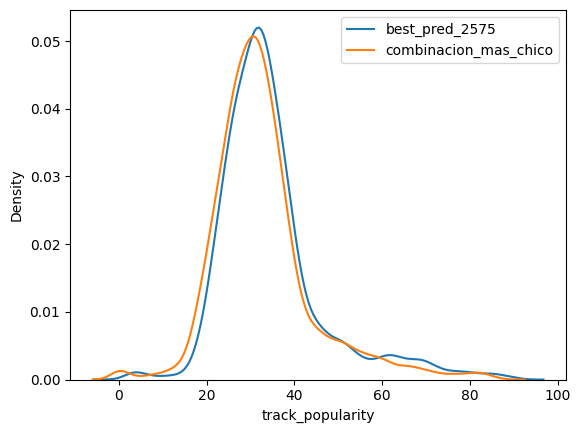

In [ ]:
sns.kdeplot(best_pred_2575['track_popularity'], label='best_pred_2575')
sns.kdeplot(combinacion_mas_chico['track_popularity'], label='combinacion_mas_chico')
plt.legend()
plt.show()

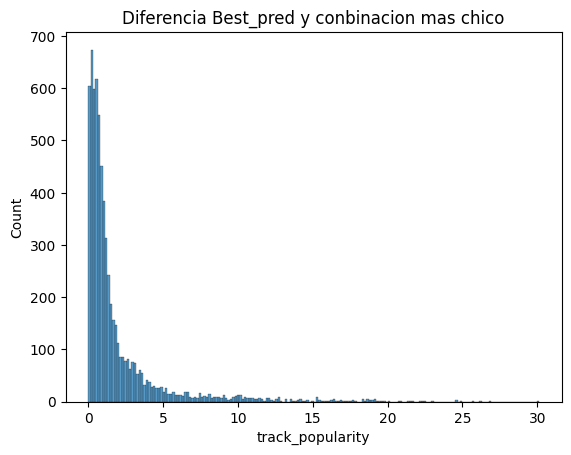

In [ ]:
sns.histplot((best_pred_2575['track_popularity'] - combinacion_mas_chico['track_popularity']))
plt.title('Diferencia Best_pred y conbinacion mas chico')
plt.show()

# Vemos que siempre best_pred es mas grande

## Combinación - 80-20 y ceros de track_id

0.40117

In [ ]:
# Submission 2 -> de cada fila, ponder 80% a track_id y 20% al otro catboost, pero si es 0 dejo 0
combinacion8020 = pd.DataFrame({
    'ID': submision_df['ID'],
    'track_popularity': np.where(submission_track_id_menos_625['track_popularity'] == 0,
                                 submission_track_id_menos_625['track_popularity'],
                                 submision_df['track_popularity']*0.2 + submission_track_id_menos_625['track_popularity']*0.8
                                 )
})

combinacion8020.to_csv('combined_2_best_8020_with0s.csv', index=False)

In [ ]:
# Leakage | track_id | combinacion 80-20
pd.concat([submision_df.describe()['track_popularity'],
           submission_track_id_menos_625.describe()['track_popularity'],
           combinacion8020.describe()['track_popularity'],
           best_pred_2575.describe()['track_popularity']], axis=1)

,track_popularity,track_popularity,track_popularity,track_popularity
count,6567.000000,6567.000000,6567.000000,6567.000000
mean,34.910352,34.505883,34.570830,34.607000
std,11.688092,12.564073,12.194412,12.065613
min,2.462751,0.000000,0.000000,0.615688
25%,27.665172,27.152988,27.355216,27.387843
50%,33.009583,32.102152,32.252180,32.308640
75%,39.204435,37.720298,37.813529,37.882575
max,86.559818,92.750000,90.711964,90.452455


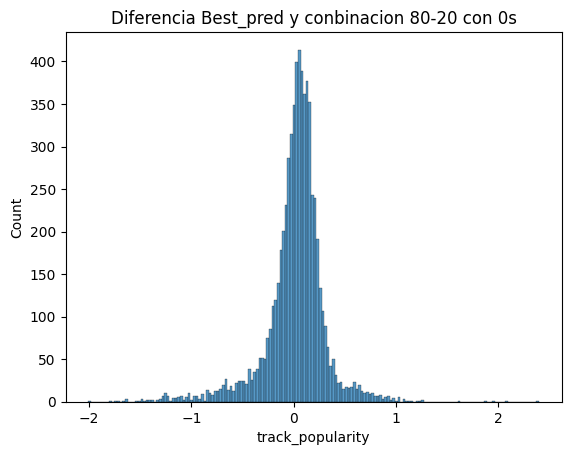

In [ ]:
no_0s = (combinacion8020['track_popularity'] != 0)
sns.histplot((best_pred_2575.loc[no_0s, 'track_popularity'] - combinacion8020.loc[no_0s, 'track_popularity']))
plt.title('Diferencia Best_pred y combinacion 80-20 con 0s')
plt.show()

## Combinacion 70-20 con 0s imputados

0.40019

Basicamente a la submission combinada con interseccion de track_id (restada en 6 unidades), le ponemos 0 donde el clasificador Catboost de 0s arroja mas de 55% de probabilidad de que sea 0, y en caso de que arroje entre 35% y 55%, ponderamos esa prediccion al 75%. Luego ponderamos la prediccion que quedo de ese modelo, y la combinamos con la prediccion del modelo con leakage en una proporcion 70-30

In [ ]:
# submission_track_id_menos_625[submission_track_id_menos_625['track_popularity']==0][['track_popularity', 'resul_classif_0']]

print(submission_track_id_menos_625[(submission_track_id_menos_625['resul_classif_0']>=0.35)&(submission_track_id_menos_625['resul_classif_0']<0.5)][['track_popularity', 'resul_classif_0']].count())

# submission_track_id_menos_625[submission_track_id_menos_625['resul_classif_0']>=0.5][['track_popularity', 'resul_classif_0']]

In [ ]:
print('Cantidad de 0s antes', submission_track_id_menos_625[submission_track_id_menos_625['track_popularity']==0].count()['track_popularity'])

def funcion_0s(row):
    if row['resul_classif_0']>0.55:
        return 0
    elif (row['resul_classif_0']>0.35) and (row['resul_classif_0']<0.55):
      return row['track_popularity']*0.75
    else:
        return row['track_popularity']

# Re-populating prediccion to ensure it reflects the expected predictions
prediccion = catboost_c.predict_proba(df_val[X_train.columns.to_list()])

submission_track_id_menos_625['resul_classif_0'] = prediccion[:,-1]

Cantidad de 0s antes 32


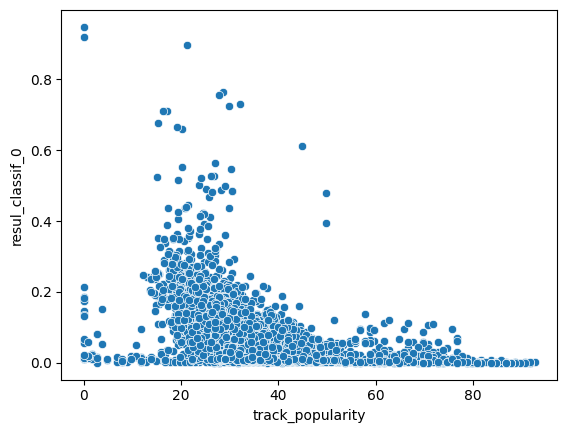

In [ ]:
sns.scatterplot(data=submission_track_id_menos_625, x='track_popularity', y='resul_classif_0')
plt.show()

In [ ]:
submission_track_id_menos_625['track_popularity'] = submission_track_id_menos_625.apply(funcion_0s, axis=1)

print('Cantidad de 0s despues', submission_track_id_menos_625[submission_track_id_menos_625['track_popularity']==0].count()['track_popularity'])

Cantidad de 0s despues 45


In [ ]:
# Submission 2 -> de cada fila, ponder 70% a track_id y 30% al otro catboost, pero si es 0 dejo 0
combinacion7030_0s = pd.DataFrame({
    'ID': submision_df['ID'],
    'track_popularity': np.where(submission_track_id_menos_625['track_popularity'] == 0,
                                 submission_track_id_menos_625['track_popularity'],
                                 submision_df['track_popularity']*0.3 + submission_track_id_menos_625['track_popularity']*0.7
                                 )
})

combinacion7030_0s.to_csv('combined_2_best_7030_with0s.csv', index=False)

In [ ]:
# Leakage | track_id | combinacion 70-30 con 0s | best_pred_25_75
pd.concat([submision_df.describe()['track_popularity'],
           submission_track_id_menos_625.describe()['track_popularity'],
           combinacion7030_0s.describe()['track_popularity'],
           best_pred_2575.describe()['track_popularity']], axis=1)

,track_popularity,track_popularity,track_popularity,track_popularity
count,6567.000000,6567.000000,6567.000000,6567.000000
mean,34.969711,33.946240,34.218172,34.607000
std,11.604405,12.559218,12.042831,12.065613
min,2.449755,0.000000,0.000000,0.615688
25%,27.765279,27.226094,27.476806,27.387843
50%,33.097147,31.582396,31.937058,32.308640
75%,39.148824,37.017642,37.413428,37.882575
max,87.367679,92.750000,90.435304,90.452455


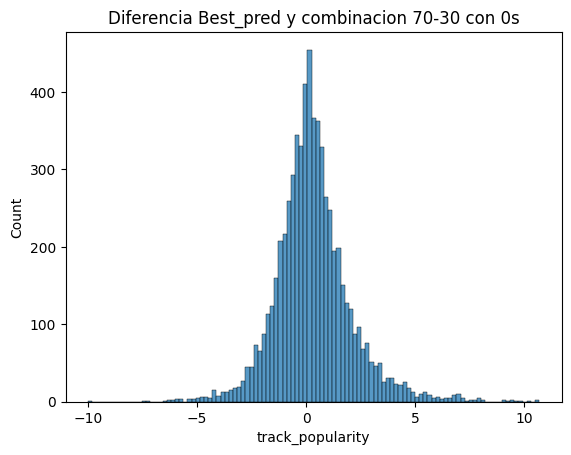

In [ ]:
no_0s = (combinacion7030_0s['track_popularity'] != 0)
sns.histplot((best_pred_2575.loc[no_0s, 'track_popularity'] - combinacion7030_0s.loc[no_0s, 'track_popularity']))
plt.title('Diferencia Best_pred y combinacion 70-30 con 0s')
plt.show()

## Ponderado por Clasificador de 0s

In [ ]:
best_pred_2575 = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/avg_leak_plus_track_id_2575.csv')

In [35]:
# No restamos nada
submision_leakage = pd.DataFrame({'ID': df_val_inicial['Unnamed: 0'],
                                  'track_popularity': y_val_predicted})

submission_track_id = pd.DataFrame({'ID': submission_df_combined_track_id['ID'],
                                    'track_popularity': submission_df_combined_track_id['track_popularity_track_id']})

In [36]:
df_submission = pd.merge(submision_leakage, submission_track_id, on='ID', how='outer')

print(f'Quedaron {df_submission.isna().sum().sum()} valores nulos')

prediccion = catboost_c.predict_proba(df_val[X_train.columns.to_list()])

df_submission['prob_no_0'] = prediccion[:,0]

Quedaron 0 valores nulos


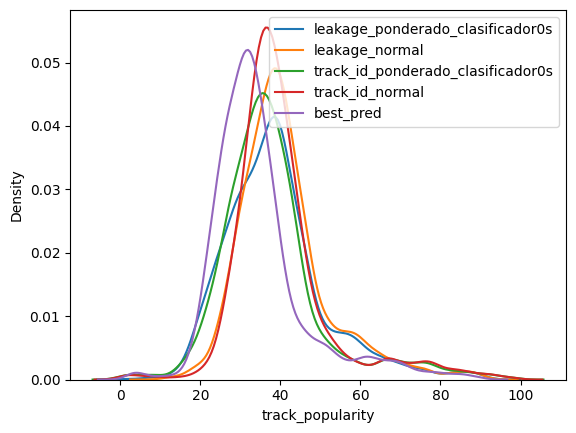

In [37]:
sns.kdeplot(submision_leakage['track_popularity']*prediccion[:,0], label='leakage_ponderado_clasificador0s')
sns.kdeplot(submision_leakage['track_popularity'], label='leakage_normal')
sns.kdeplot(submission_track_id['track_popularity']*prediccion[:,0], label='track_id_ponderado_clasificador0s')
sns.kdeplot(submission_track_id['track_popularity'], label='track_id_normal')
sns.kdeplot(best_pred_2575['track_popularity'], label='best_pred')
plt.legend(loc='upper right')
plt.show()

In [ ]:
# Leakage ponderado | Leakage | Track_id ponderado | Track_id ponderado^2 | Track_id | best_pred
pd.concat([(submision_leakage['track_popularity']*prediccion[:,0]).describe(),
           submision_leakage['track_popularity'].describe(),
           (submission_track_id['track_popularity']*prediccion[:,0]).describe(),
            (submission_track_id['track_popularity']*prediccion[:,0]**2).describe(),
           submission_track_id['track_popularity'].describe(),
           best_pred_2575['track_popularity'].describe() ], axis=1)

,track_popularity,track_popularity,track_popularity,track_popularity,track_popularity,track_popularity
count,6567.000000,6567.000000,6567.000000,6567.000000,6567.000000,6567.000000
mean,38.611684,40.969711,37.916676,35.906929,40.266150,34.607000
std,12.755307,11.604405,13.431577,14.327159,12.498706,12.065613
min,0.813447,8.449755,0.000000,0.000000,0.000000,0.615688
25%,30.159932,33.765279,30.216090,27.008735,33.497779,27.387843
50%,37.416333,39.097147,35.981108,34.503255,37.834264,32.308640
75%,43.836327,45.148824,42.052566,41.045485,43.270228,37.882575
max,93.309240,93.367679,98.794786,98.589998,99.000000,90.452455


Kaggle: 0.39651

In [41]:
# Prediccion Track_id ponderada por prediccion del clasificador de 0s

df_ponderado = pd.DataFrame(
    {'ID': df_val['Unnamed: 0'], # cambie df_val_inicial por df_val
        'track_popularity': submission_track_id['track_popularity']*prediccion[:,0]
    }
)
# df_ponderado.to_csv('catboost_track_id_ponderado_clasificador0s.csv', index=False)

Kaggle: 0.42878

In [42]:
# Prediccion Track_id ponderada por prediccion del clasificador de 0s

df_ponderado_2 = pd.DataFrame(
    {'ID': df_val['Unnamed: 0'], # cambie df_val_inicial por df_val
        'track_popularity': submission_track_id['track_popularity']*prediccion[:,0]**2
    }
)
# df_ponderado_2.to_csv('catboost_track_id_ponderado^2_clasificador0s.csv', index=False)

Kaggle: 0.43736

In [43]:
# Prediccion Track_id ponderada por prediccion del clasificador de 0s

df_ponderado_3 = pd.DataFrame(
    {'ID': df_val['Unnamed: 0'],
        'track_popularity': submission_track_id['track_popularity']*prediccion[:,0]**3
    }
)
# df_ponderado_3.to_csv('catboost_track_id_ponderado^3_clasificador0s.csv', index=False)

Kaggle: 0.43077

In [44]:
# Prediccion Track_id ponderada por prediccion del clasificador de 0s

df_ponderado_4 = pd.DataFrame(
    {'ID': df_val['Unnamed: 0'],
        'track_popularity': submission_track_id['track_popularity']*prediccion[:,0]**4
    }
)
# df_ponderado_4.to_csv('catboost_track_id_ponderado^4_clasificador0s.csv', index=False)

Comparamos

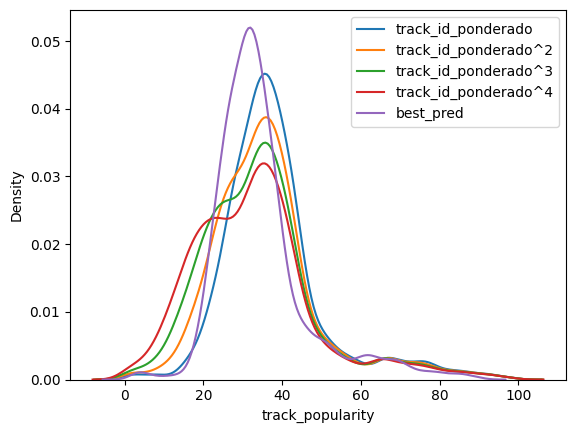

In [ ]:
sns.kdeplot(df_ponderado['track_popularity'], label='track_id_ponderado')
sns.kdeplot(df_ponderado_2['track_popularity'], label='track_id_ponderado^2')
sns.kdeplot(df_ponderado_3['track_popularity'], label='track_id_ponderado^3')
sns.kdeplot(df_ponderado_4['track_popularity'], label='track_id_ponderado^4')
sns.kdeplot(best_pred_2575['track_popularity'], label='best_pred')
plt.legend(loc='upper right')
plt.show()

In [ ]:
# Track_id ponderado | Track_id ponderado^2 | Track_id ponderado^3 | best_pred
pd.concat([df_ponderado.describe()['track_popularity'],
           df_ponderado_2.describe()['track_popularity'],
           df_ponderado_3.describe()['track_popularity'],
           df_ponderado_4.describe()['track_popularity'],
           best_pred_2575['track_popularity'].describe() ], axis=1)

,track_popularity,track_popularity,track_popularity,track_popularity,track_popularity
count,6567.000000,6567.000000,6567.000000,6567.000000,6567.000000
mean,37.916676,35.906929,34.154789,32.609617,34.607000
std,13.431577,14.327159,15.115924,15.795708,12.065613
min,0.000000,0.000000,0.000000,0.000000,0.615688
25%,30.216090,27.008735,24.305680,21.640062,27.387843
50%,35.981108,34.503255,33.269950,32.041670,32.308640
75%,42.052566,41.045485,40.414614,39.655233,37.882575
max,98.794786,98.589998,98.385635,98.181695,90.452455


Probamos ponderar las predicciones del modelo de data_leakage

In [22]:
new_best_pred = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/catboost_track_id_ponderado%5E3_clasificador0s.csv')

Kaggle: ?

In [19]:
# Prediccion submision_leakage ponderada por prediccion del clasificador de 0s

df_ponderado_DL = pd.DataFrame(
    {'ID': df_val['Unnamed: 0'], # cambie df_val_inicial por df_val
        'track_popularity': submision_leakage['track_popularity']*prediccion[:,0]
    }
)
# df_ponderado_DL.to_csv('catboost_track_id_ponderado_clasificador0s.csv', index=False)

Kaggle: ?

In [20]:
# Prediccion submision_leakage ponderada por prediccion del clasificador de 0s

df_ponderado_2_DL = pd.DataFrame(
    {'ID': df_val['Unnamed: 0'], # cambie df_val_inicial por df_val
        'track_popularity': submision_leakage['track_popularity']*prediccion[:,0]**2
    }
)
# df_ponderado_2_DL.to_csv('catboost_track_id_ponderado^2_clasificador0s.csv', index=False)

Kaggle: 0.41053

In [45]:
# Prediccion submision_leakage ponderada por prediccion del clasificador de 0s

df_ponderado_3_DL = pd.DataFrame(
    {'ID': df_val['Unnamed: 0'], # cambie df_val_inicial por df_val
        'track_popularity': submision_leakage['track_popularity']*prediccion[:,0]**3
    }
)
# df_ponderado_3_DL.to_csv('catboost_leakage_ponderado^3_clasificador0s.csv', index=False)

Kaggle: ?

In [38]:
# Prediccion submision_leakage ponderada por prediccion del clasificador de 0s

df_ponderado_4_DL = pd.DataFrame(
    {'ID': df_val['Unnamed: 0'], # cambie df_val_inicial por df_val
        'track_popularity': submision_leakage['track_popularity']*prediccion[:,0]**4
    }
)
# df_ponderado_4_DL.to_csv('catboost_leakage_ponderado^4_clasificador0s.csv', index=False)

Kaggle: ?

In [50]:
# Prediccion submision_leakage ponderada por prediccion del clasificador de 0s

df_ponderado_5_DL = pd.DataFrame(
    {'ID': df_val['Unnamed: 0'], # cambie df_val_inicial por df_val
        'track_popularity': submision_leakage['track_popularity']*prediccion[:,0]**5
    }
)
# df_ponderado_5_DL.to_csv('catboost_leakage_ponderado^5_clasificador0s.csv', index=False)

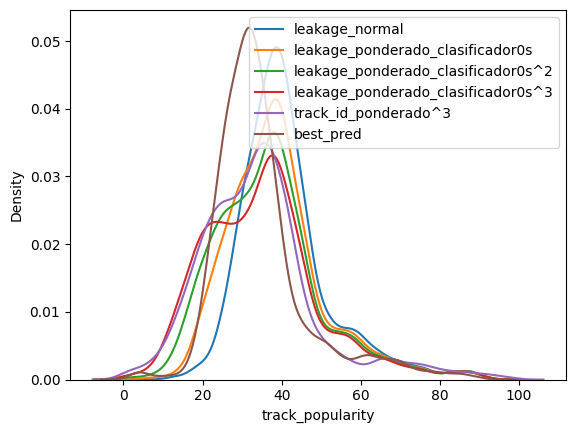

In [28]:
sns.kdeplot(submision_leakage['track_popularity'], label='leakage_normal')
sns.kdeplot(df_ponderado_DL['track_popularity'], label='leakage_ponderado_clasificador0s')
sns.kdeplot(df_ponderado_2_DL['track_popularity'], label='leakage_ponderado_clasificador0s^2')
sns.kdeplot(df_ponderado_3_DL['track_popularity'], label='leakage_ponderado_clasificador0s^3')
sns.kdeplot(new_best_pred['track_popularity'], label='track_id_ponderado^3')
sns.kdeplot(best_pred_2575['track_popularity'], label='best_pred')
plt.legend(loc='upper right')
plt.show()

In [51]:
# Leakage ponderado | Leakage | Track_id ponderado | Track_id ponderado^2 | Track_id | best_pred
pd.concat([submision_leakage['track_popularity'].describe(),

           df_ponderado_DL['track_popularity'].describe(),
           df_ponderado.describe()['track_popularity'],

           df_ponderado_2_DL['track_popularity'].describe(),
           df_ponderado_2.describe()['track_popularity'],

           df_ponderado_3_DL['track_popularity'].describe(),
           df_ponderado_3.describe()['track_popularity'],

           df_ponderado_4_DL['track_popularity'].describe(),
           df_ponderado_4.describe()['track_popularity'],

           df_ponderado_5_DL['track_popularity'].describe(),

           best_pred_2575['track_popularity'].describe()], axis=1)

,track_popularity,track_popularity,track_popularity,track_popularity,track_popularity,track_popularity,track_popularity,track_popularity,track_popularity,track_popularity,track_popularity
count,6567.000000,6567.000000,6567.000000,6567.000000,6567.000000,6567.000000,6567.000000,6567.000000,6567.000000,6567.000000,6567.000000
mean,40.969711,38.611684,37.916676,36.591482,35.906929,34.827761,34.154789,33.270741,32.609617,31.884826,34.607000
std,11.604405,12.755307,13.431577,13.792810,14.327159,14.684051,15.115924,15.439451,15.795708,16.076269,12.065613
min,8.449755,0.813447,0.000000,0.042726,0.000000,0.002244,0.000000,0.000118,0.000000,0.000006,0.615688
25%,33.765279,30.159932,30.216090,26.916646,27.008735,23.973563,24.305680,21.455859,21.640062,19.216955,27.387843
50%,39.097147,37.416333,35.981108,36.014439,34.503255,34.572139,33.269950,33.091046,32.041670,31.738331,32.308640
75%,45.148824,43.836327,42.052566,42.867561,41.045485,42.082989,40.414614,41.414077,39.655233,40.760748,37.882575
max,93.367679,93.309240,98.794786,93.250839,98.589998,93.192473,98.385635,93.134145,98.181695,93.075852,90.452455


Kaggle: 0.44121

Probamos hacer el data leakage ponderada^4 * 0.25 y track_id ponderada^3 *0.75

In [48]:
submission1 = pd.DataFrame({
    'ID': submision_df['ID'],
    'track_popularity': df_ponderado_4_DL['track_popularity']*0.25 + df_ponderado_3['track_popularity']*0.75
})

submission1.to_csv('leakage_ponderado^4_025_track_id_ponderado^3_075.csv', index=False)

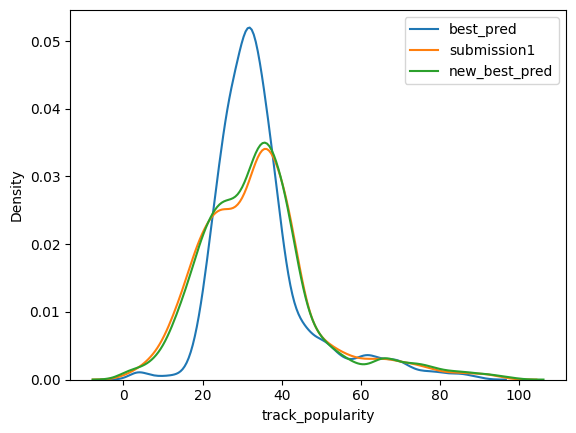

In [49]:
sns.kdeplot(best_pred_2575['track_popularity'], label='best_pred')
sns.kdeplot(submission1['track_popularity'], label='submission1')
sns.kdeplot(new_best_pred['track_popularity'], label='new_best_pred')
plt.legend()
plt.show()

PROBAR 50-50 y con ponderado a la 5


Probar Adversarial Validation ponderada